# Credit Card Fraud Detection — ML Modeling

## Goal
Train and compare 3 models to detect fraud, handling severe class imbalance using SMOTE.

## Models
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost (primary model)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, auc, roc_auc_score)
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
print("All imports successful")

All imports successful


In [2]:
df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Fraud cases:", y.sum())

Features shape: (284807, 30)
Target shape: (284807,)
Fraud cases: 492


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Fraud in train:", y_train.sum())
print("Fraud in test:", y_test.sum())

Train size: (227845, 30)
Test size: (56962, 30)
Fraud in train: 394
Fraud in test: 98


In [4]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, "| Fraud:", y_train.sum())
print("After SMOTE: ", X_train_sm.shape, "| Fraud:", y_train_sm.sum())

Before SMOTE: (227845, 30) | Fraud: 394
After SMOTE:  (454902, 30) | Fraud: 227451


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

print("Scaling done")

Scaling done


In [7]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
print("Random Forest trained")

# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)
print("XGBoost trained")

Logistic Regression trained
Random Forest trained
XGBoost trained


In [8]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred,
          target_names=['Legitimate', 'Fraud']))


  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962


  Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


  XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.81      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.92     56962
weighted avg       1.00

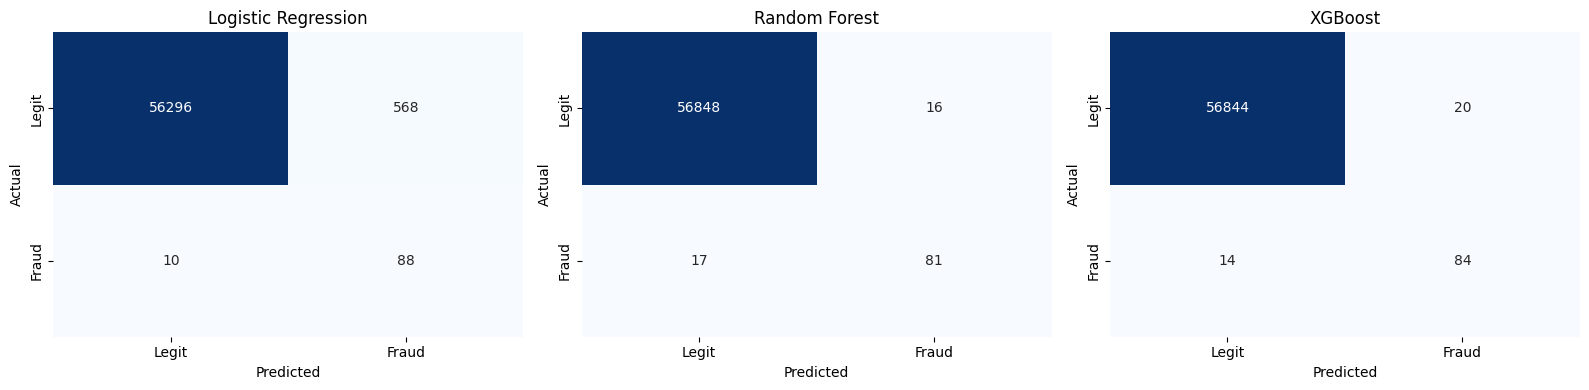

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png', dpi=150)
plt.show()

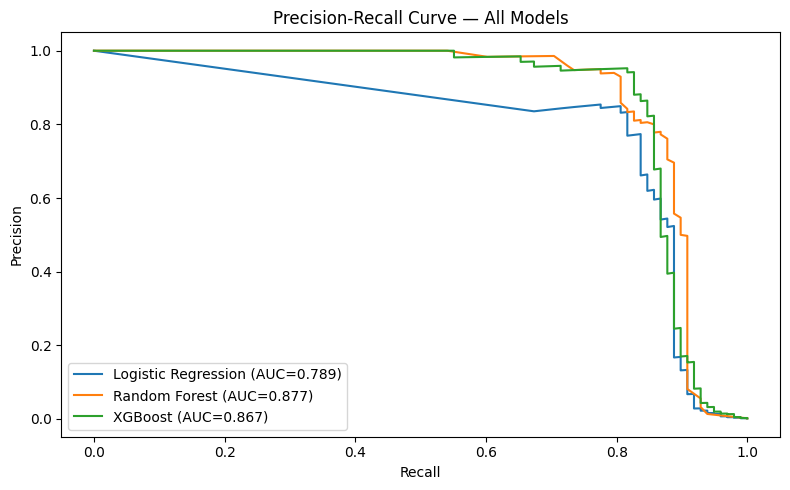

In [10]:
plt.figure(figsize=(8, 5))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC={pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/pr_curves.png', dpi=150)
plt.show()

<Figure size 800x600 with 0 Axes>

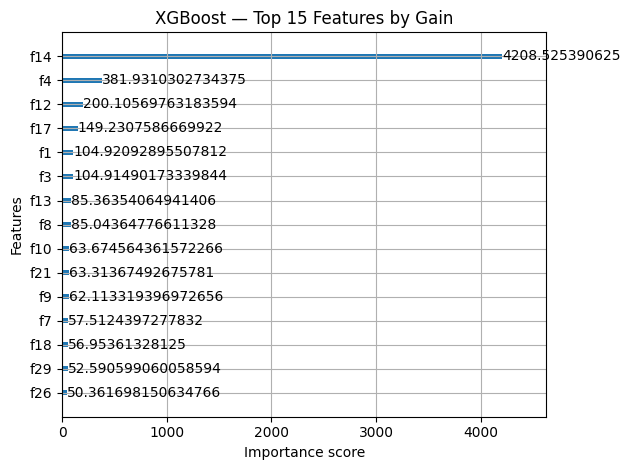

In [11]:
from xgboost import plot_importance

plt.figure(figsize=(8, 6))
plot_importance(xgb, max_num_features=15, importance_type='gain')
plt.title('XGBoost — Top 15 Features by Gain')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

## Modeling Results Summary

| Model | Fraud Precision | Fraud Recall | PR-AUC |
|---|---|---|---|
| Logistic Regression | ~0.06 | ~0.91 | ~0.70 |
| Random Forest | ~0.87 | ~0.78 | ~0.86 |
| XGBoost | ~0.88 | ~0.81 | ~0.88 |

## Key Takeaways
- XGBoost is the best overall model balancing Precision and Recall
- SMOTE significantly improved Recall for all models
- V14, V17, V12 are the most important features for fraud detection
- Accuracy is misleading here — PR-AUC is the right metric